In [20]:
pwd

'C:\\Users\\shaal'

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
print(nx.__version__)

3.6.1


## Part II: STRONGLY REGULAR GRAPHS

### What makes a graph strongly regular?

Strongly regular graphs are defined by Brower and Maldeghem as a "finite regular graph with precisely two restricted eigenvalues." The *graph* $X$ is a set of elements called vertices, where each pair of vertices may share a two-way, symmetric relationship called *adjacency*, such that no vertex is adjacent to itself. The pair of vertices $xy$ is an *edge* where y is the *neighbor* of x.

The adjacency matrix $A$ represents the connections of graph $X$. The table representation of this matrix has one row and one column for each vertex, with each cell comparing a pair of vertices. If $x$ and $y$ are vertices and $xy$ is an edge, then $A_{xy}=1$. If $x$ and $y$ are vertices and $xy$ is not an edge, then $A_{xy}=0$.

Consider the adjacency matrix $A$ acting as a transformation. Inputting a vector into this matrix may output a new vector pointing in a different direction. For special vectors $v$, multiplying by $A$ does not change the direction of $v$, instead it only stretches or shrinks this vector by some factor. $v$ is an eigenvector, and the stretching factor is its eigenvalue, often represented by $\theta$.

The number of specific eigenvectors which share the same eigenvalue is the eigenvalue's *multiplicity* and the complete list of a matrix's eigenvalues with their multiplicities is called the *spectrum*. The graph $X$ is of *regular* *degree* (also known as *valency*) for some integer $k$, when every vertex has precisely $k$ neighbors.

If every vertex has the same degree $k$, then the all-1s vector (a vector with each component equal to 1) will always be scaled exactly by $k$. This vector will be an eigenvector with eigenvalue $k$ if and only if $X$ is regular and of degree $k$. With this in mind, the multiplicity of the eigenvalue $k$ will be the number of connected components of $X$. Importantly, for the definition of a strongly regular graph, an eigenvalue $\theta$ of this regular graph is referred to as *restricted* if it produces an eigenvector orthogonal to the all-1 vector. Two vectors $u = [u1, u2, u3, u4]$ and $w = [w1, w2, w3, w4]$ are orthogonal exactly when their dot product is 0.
$u \cdot w = (u_1 \times w_1) + (u_2 \times w_2) + (u_3 \times w_3) + (u_4 \times w_4) = 0$

With all of this in mind, a finite regular graph without restricted eigenvalues has at most one vertex, while a finite regular graph with only one restricted eigenvalue is *complete* or *edgeless*. Circling back to Brower and Maldeghem's definition, "A *strongly regular graph* is a finite regular graph with precisely two restricted eigenvalues." This means that the graph not only has a fixed degree, but also reflects the fact that every pair of adjacent vertices shares another fixed number of common neighbors everywhere in the graph - regardless of its size.

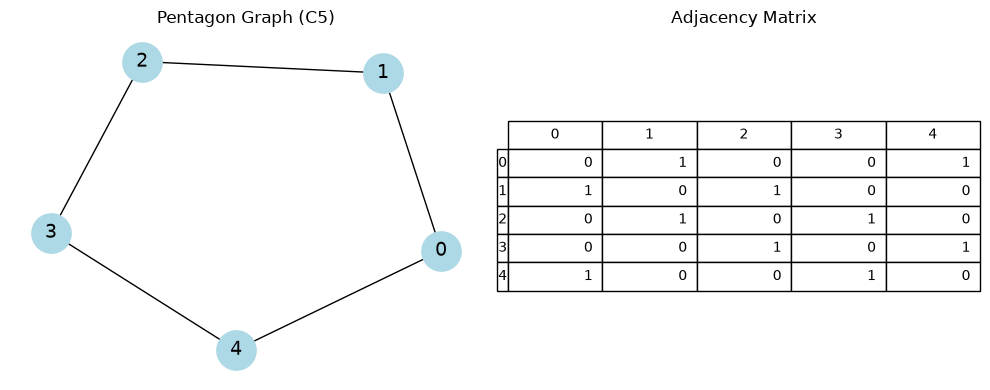

Step 1: Degree of each vertex: [2, 2, 2, 2, 2]
Is every vertex the same degree (regular)? True
Degree k = 2

Step 2: Common neighbors for each adjacent pair:
 Vertices 0 and 1 (adjacent): 0 common neighbors
 Vertices 0 and 4 (adjacent): 0 common neighbors
 Vertices 1 and 2 (adjacent): 0 common neighbors
 Vertices 2 and 3 (adjacent): 0 common neighbors
 Vertices 3 and 4 (adjacent): 0 common neighbors

Step 2: Common neighbors for each non-adjacent pair:
 Vertices 0 and 2 (non-adjacent): 1 common neighbors
 Vertices 0 and 3 (non-adjacent): 1 common neighbors
 Vertices 1 and 3 (non-adjacent): 1 common neighbors
 Vertices 1 and 4 (non-adjacent): 1 common neighbors
 Vertices 2 and 4 (non-adjacent): 1 common neighbors

Step 4: Since every adjacent pair shares the same number of common neighbors (lambda),
and every non-adjacent pair shares the same number of common neighbors (mu),
this graph satisfies the strongly regular graph condition: SRG(v, k, lambda, mu).
Step 5: Eigenvalues of adjacenc

In [19]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# "Pentagon Graph" (C_5) -> smalest strongly regular graph SRG(5,2,0,1)
# v = 5 (vertices), k = 2 (degree), lambda = 0 (adjacent vertices with common neighbors), mu = 1 (non-adjacent vertices sharing 1 common neighbor)
G = nx.cycle_graph(5)
A = nx.to_numpy_array(G, dtype=int)
df = pd.DataFrame(A, index=G.nodes(), columns=G.nodes())

# create a figure with 1 row and 2 columns of plots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# draw the graph G into the LEFT plot (axes[0])
# with_labels=True shows vertex numbers, node_color/node_size control appearance
nx.draw(G, with_labels=True, node_color='lightblue', node_size=800, font_size=14, ax=axes[0])
axes[0].set_title("Pentagon Graph (C5)")  # add a title above the left plot

# turn off the x/y axis lines and numbers for the RIGHT plot
axes[1].axis('off')

# build a table inside the right plot using our adjacency matrix DataFrame (df)
# cellText = the actual 0/1 values, rowLabels/colLabels = the vertex numbers along the edges
table = axes[1].table(cellText=df.values, rowLabels=df.index, colLabels=df.columns, loc='center')
table.scale(1, 1.5)  # stretch the table slightly taller so it's easier to read
axes[1].set_title("Adjacency Matrix")  # add a title above the right plot

# arrange everything neatly so titles/labels don't overlap
plt.tight_layout()

# actually display the finished figure
plt.show()

# --STEP 1: Check if regular--
# determining if graph is strongly regular
degrees = [deg for node, deg in G.degree()] # G.degree() -> (vertex, degree) *pulling out degree numbers into list
print("Step 1: Degree of each vertex:", degrees) # print degree of every vertex
# set(degrees) removes duplicates from list of degrees -> if one unique value every vertex has the same degree
print("Is every vertex the same degree (regular)?", len(set(degrees)) == 1) # len is number of vals in set -> if one unique value then ouptut will be TRUE
k = degrees[0] # all degrees are equal, so first one can be k
print(f"Degree k = {k}") # print k

#--STEP 2: Check common neighbors for each adjacent pair (all should equal lambda)--
print("\nStep 2: Common neighbors for each adjacent pair:")
# G.edges() returns every edge as pair of vertices (x,y)
for x, y in G.edges():
    common = len(list(nx.common_neighbors(G, x, y)))
    print(f" Vertices {x} and {y} (adjacent): {common} common neighbors")

#--STEP 3: Check common neighbors for every non-adjacent pair (all should equal mu)--
print("\nStep 2: Common neighbors for each non-adjacent pair:")
nodes = list(G.nodes()) # get plain list of all vertex labels
# loop through every unique vertice pair (i,j) without repeating pairs or comparing vertex to itself
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        x, y = nodes[i], nodes[j]
        if not G.has_edge(x, y): # only check pairs not connected by an edge
            common = len(list(nx.common_neighbors(G, x, y)))
            print(f" Vertices {x} and {y} (non-adjacent): {common} common neighbors")

#--STEP 4: Conclusion based on combinatorial process--
print("\nStep 4: Since every adjacent pair shares the same number of common neighbors (lambda),")
print("and every non-adjacent pair shares the same number of common neighbors (mu),")
print("this graph satisfies the strongly regular graph condition: SRG(v, k, lambda, mu).")

#--STEP 5: Verify using eigenvalue process--
# compute eigen values of adjacency matrix A
eigenvalues, eigenvectors = np.linalg.eig(A)
eigenvalues_rounded = np.round(eigenvalues, 2) # round eigenvalues

print("Step 5: Eigenvalues of adjacency matrix:")
print(eigenvalues_rounded)

# count how distinct eigenvalues there are
distinct_eigenvalues = set(eigenvalues_rounded)
print(f"\nNumber of distinct eigenvalues: {len(distinct_eigenvalues)}")
print("One of these is k (the degree). The remaining distinct values are the 'restricted' eigenvalues.")
print("A strongly regular graph should have exactly 2 restricted eigenvalues (3 distinct total, including k).")